In [1]:
!pip install pandas matplotlib seaborn datasets numpy wordcloud

In [2]:
#EDA  and Analysis of sensitive data in text files

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
import numpy as np
from collections import Counter
import re
from wordcloud import WordCloud

o:\REDACTION_SYSTEM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
print("\nLoading dataset...")
dataset = load_from_disk("./pii_dataset")

# Convert to pandas for easier analysis
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])


Loading dataset...



[1/8] Creating class distribution plots...


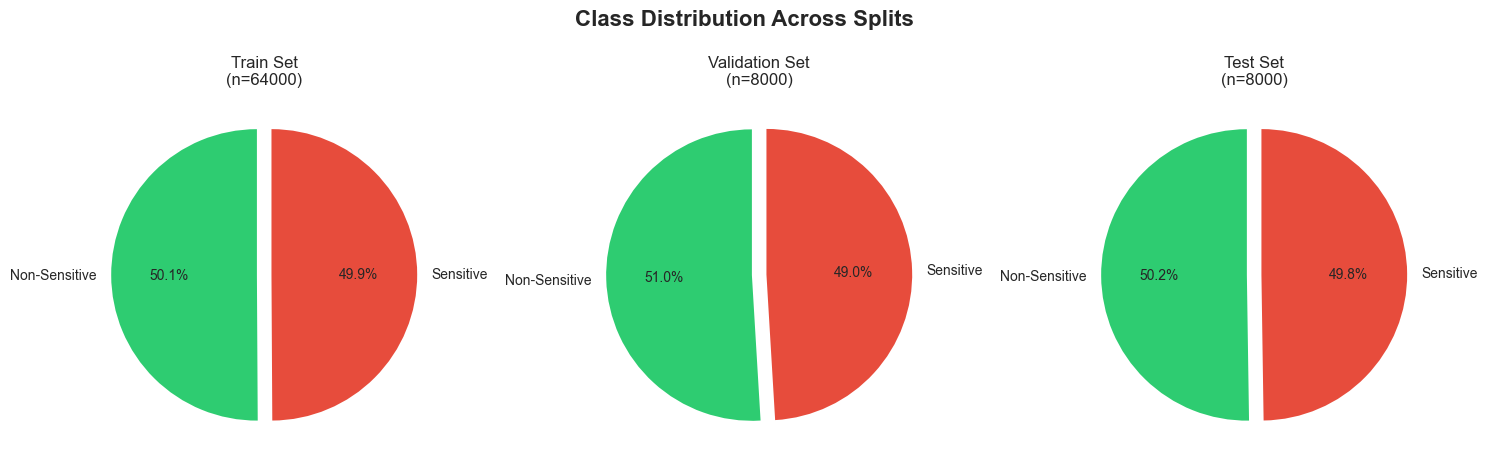

In [6]:
print("\n[1/8] Creating class distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Class Distribution Across Splits', fontsize=16, fontweight='bold')

# Train
train_counts = train_df['label'].value_counts()
axes[0].pie(train_counts, labels=['Non-Sensitive', 'Sensitive'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0.05))
axes[0].set_title(f'Train Set\n(n={len(train_df)})')

# Validation
val_counts = val_df['label'].value_counts()
axes[1].pie(val_counts, labels=['Non-Sensitive', 'Sensitive'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0.05))
axes[1].set_title(f'Validation Set\n(n={len(val_df)})')

# Test
test_counts = test_df['label'].value_counts()
axes[2].pie(test_counts, labels=['Non-Sensitive', 'Sensitive'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0.05))
axes[2].set_title(f'Test Set\n(n={len(test_df)})')

plt.tight_layout()


[2/8] Creating category breakdown...


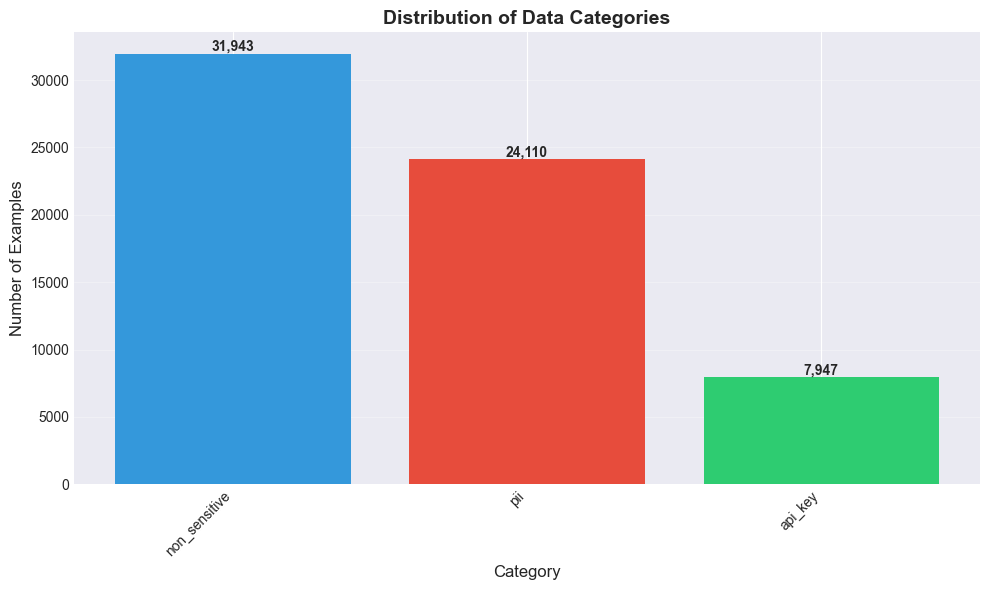

In [7]:
print("\n[2/8] Creating category breakdown...")

fig, ax = plt.subplots(figsize=(10, 6))
category_counts = train_df['category'].value_counts()

bars = ax.bar(range(len(category_counts)), category_counts.values, 
              color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax.set_ylabel('Number of Examples', fontsize=12)
ax.set_xlabel('Category', fontsize=12)
ax.set_title('Distribution of Data Categories', fontsize=14, fontweight='bold')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


[3/8] Analyzing text length distribution...


C:\Users\gnana\AppData\Local\Temp\ipykernel_10228\2964903787.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1, 0].boxplot(data_to_plot, labels=['Non-Sensitive', 'Sensitive'],
C:\Users\gnana\AppData\Local\Temp\ipykernel_10228\2964903787.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(data_to_plot, labels=['Non-Sensitive', 'Sensitive'],


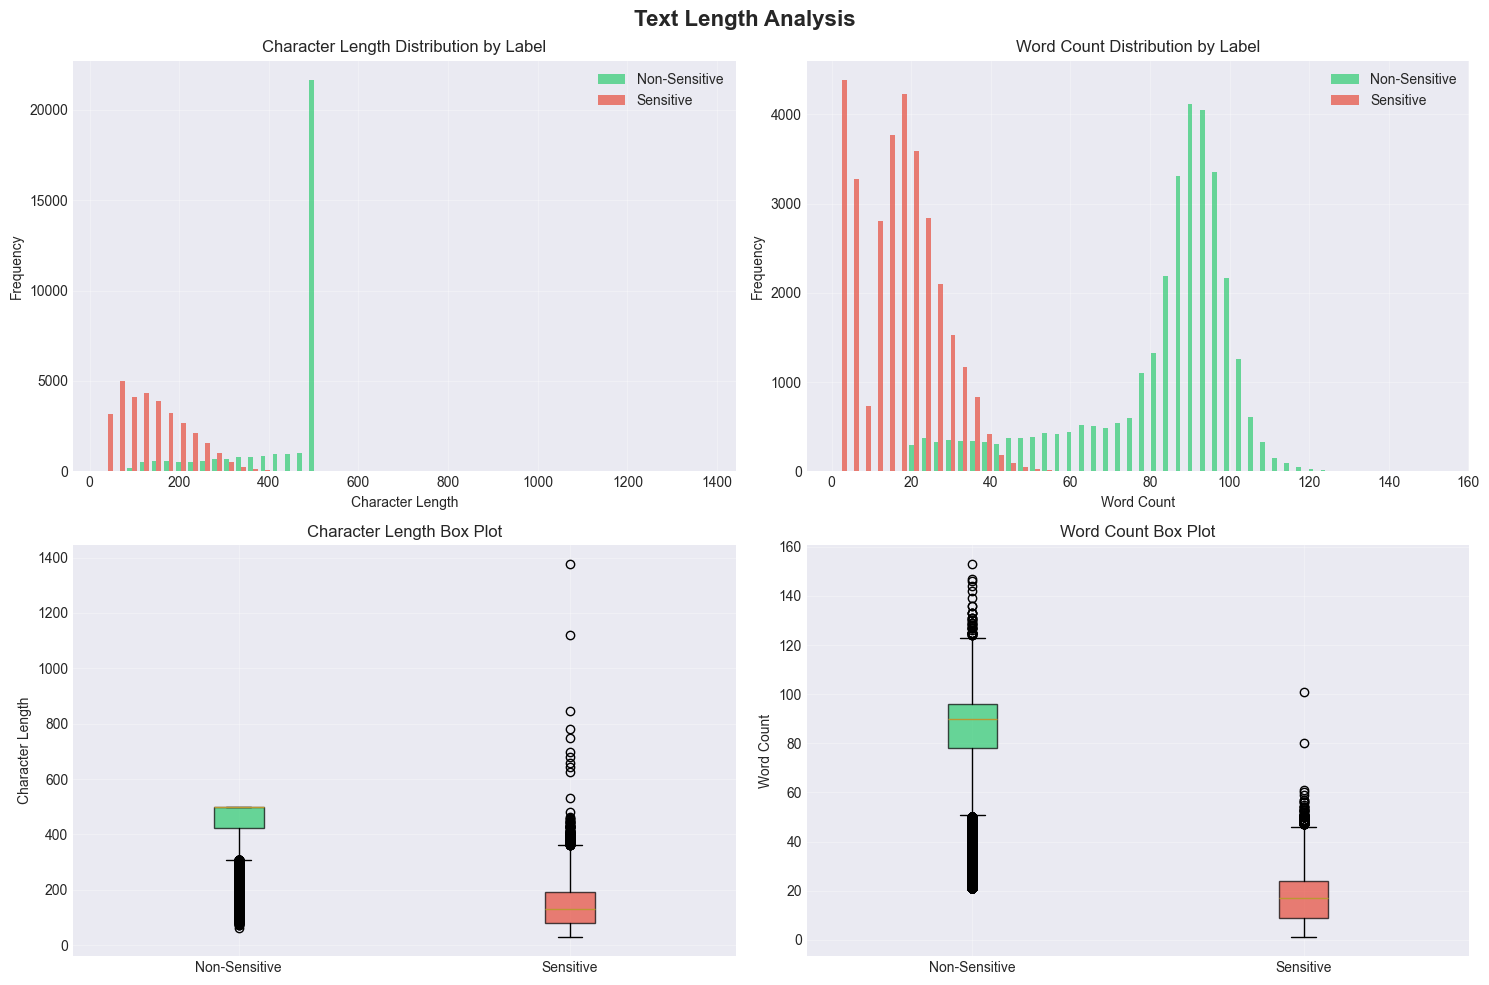

In [8]:
print("\n[3/8] Analyzing text length distribution...")

train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Text Length Analysis', fontsize=16, fontweight='bold')

# Character length by label
axes[0, 0].hist([train_df[train_df['label']==0]['text_length'],
                 train_df[train_df['label']==1]['text_length']],
                bins=50, label=['Non-Sensitive', 'Sensitive'], 
                color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Character Length Distribution by Label')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count by label
axes[0, 1].hist([train_df[train_df['label']==0]['word_count'],
                 train_df[train_df['label']==1]['word_count']],
                bins=50, label=['Non-Sensitive', 'Sensitive'], 
                color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Word Count Distribution by Label')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot - Character length
data_to_plot = [train_df[train_df['label']==0]['text_length'],
                train_df[train_df['label']==1]['text_length']]
bp1 = axes[1, 0].boxplot(data_to_plot, labels=['Non-Sensitive', 'Sensitive'],
                          patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_ylabel('Character Length')
axes[1, 0].set_title('Character Length Box Plot')
axes[1, 0].grid(alpha=0.3)

# Box plot - Word count
data_to_plot = [train_df[train_df['label']==0]['word_count'],
                train_df[train_df['label']==1]['word_count']]
bp2 = axes[1, 1].boxplot(data_to_plot, labels=['Non-Sensitive', 'Sensitive'],
                          patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_title('Word Count Box Plot')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()



[4/8] Creating statistics summary...

Statistics by Label:
      text_length                          word_count                       
             mean median     std min   max       mean median    std min  max
label                                                                       
0          441.24  500.0  105.81  63   500      82.66   90.0  20.68  21  153
1          143.28  132.0   75.19  28  1377      17.21   17.0   9.99   1  101

Statistics by Category:
              text_length                word_count              
                     mean median     std       mean median    std
category                                                         
api_key             60.74   58.0   15.58       4.40    4.0   2.17
non_sensitive      441.24  500.0  105.81      82.66   90.0  20.68
pii                170.48  159.0   66.71      21.43   20.0   7.69


Text(0.5, 1.0, 'Dataset Statistics Summary')

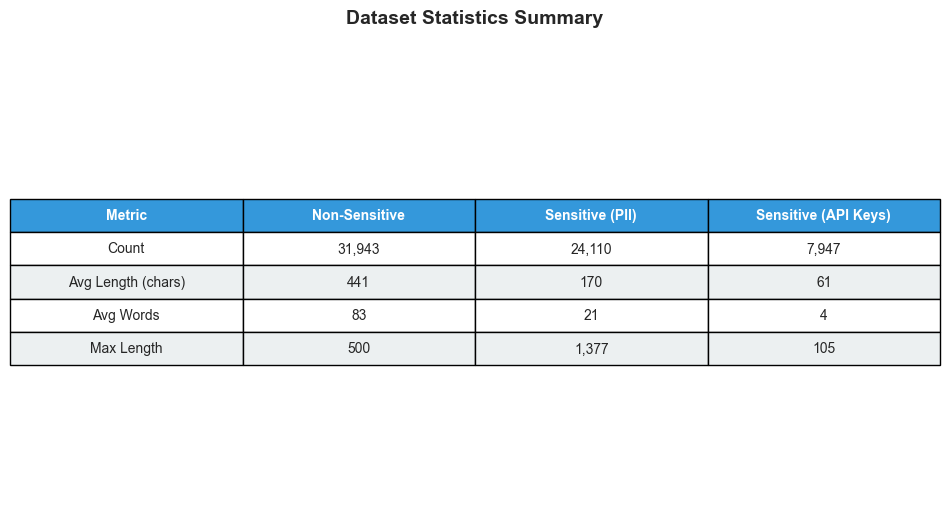

In [9]:
print("\n[4/8] Creating statistics summary...")

stats_by_label = train_df.groupby('label').agg({
    'text_length': ['mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

stats_by_category = train_df.groupby('category').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std']
}).round(2)

print("\nStatistics by Label:")
print(stats_by_label)

print("\nStatistics by Category:")
print(stats_by_category)

# Create visualization of statistics
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Metric', 'Non-Sensitive', 'Sensitive (PII)', 'Sensitive (API Keys)'],
    ['Count', 
     f"{len(train_df[train_df['category']=='non_sensitive']):,}",
     f"{len(train_df[train_df['category']=='pii']):,}",
     f"{len(train_df[train_df['category']=='api_key']):,}"],
    ['Avg Length (chars)', 
     f"{train_df[train_df['category']=='non_sensitive']['text_length'].mean():.0f}",
     f"{train_df[train_df['category']=='pii']['text_length'].mean():.0f}",
     f"{train_df[train_df['category']=='api_key']['text_length'].mean():.0f}"],
    ['Avg Words', 
     f"{train_df[train_df['category']=='non_sensitive']['word_count'].mean():.0f}",
     f"{train_df[train_df['category']=='pii']['word_count'].mean():.0f}",
     f"{train_df[train_df['category']=='api_key']['word_count'].mean():.0f}"],
    ['Max Length', 
     f"{train_df[train_df['category']=='non_sensitive']['text_length'].max():,}",
     f"{train_df[train_df['category']=='pii']['text_length'].max():,}",
     f"{train_df[train_df['category']=='api_key']['text_length'].max():,}"],
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')

plt.title('Dataset Statistics Summary', fontsize=14, fontweight='bold', pad=20)


[6/8] Generating word clouds...


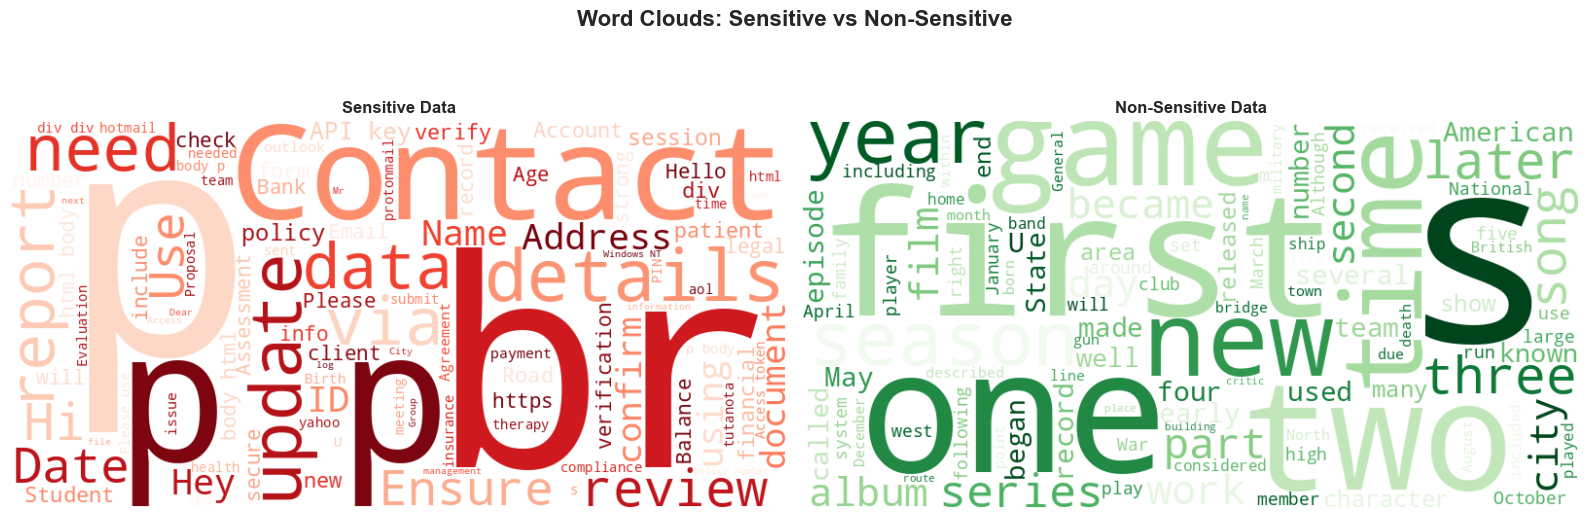

In [10]:
print("\n[6/8] Generating word clouds...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds: Sensitive vs Non-Sensitive', fontsize=16, fontweight='bold')

# Sensitive word cloud
sensitive_text = ' '.join(train_df[train_df['label']==1]['text'].head(1000))
wordcloud_sensitive = WordCloud(width=800, height=400, 
                                background_color='white',
                                colormap='Reds',
                                max_words=100).generate(sensitive_text)
axes[0].imshow(wordcloud_sensitive, interpolation='bilinear')
axes[0].set_title('Sensitive Data', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Non-sensitive word cloud
non_sensitive_text = ' '.join(train_df[train_df['label']==0]['text'].head(1000))
wordcloud_non_sensitive = WordCloud(width=800, height=400,
                                    background_color='white',
                                    colormap='Greens',
                                    max_words=100).generate(non_sensitive_text)
axes[1].imshow(wordcloud_non_sensitive, interpolation='bilinear')
axes[1].set_title('Non-Sensitive Data', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()

In [11]:
train_df.head(5)

,text,label,category,text_length,word_count
0,Can you send updates on services in 67561? Con...,1,pii,104,20
1,Just saw Bedford High’s new admissions form. T...,1,pii,103,13
2,"During the earlier seasons of the show , Magg...",0,non_sensitive,308,63
3,"After departing Fremantle , the convoy steame...",0,non_sensitive,500,90
4,Wonderful explanation on self-concept. Residen...,1,pii,130,18


In [12]:
# !pip install pandas torch transformers scikit-learn

In [13]:
# !pip install "accelerate>=0.26.0"


In [14]:
#Training the distilBert Model for sensitive data Detection

In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModelForSequenceClassification.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2",
    num_labels=2
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
import pandas as pd
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import re


# =========================================================
# Load Dataset
# =========================================================
df = train_df.head(100)   # use your subset for quick testing
print("Dataset shape:", df.shape)
print(df.head())


# =========================================================
# Split into train/test
# =========================================================
texts = df["text"].tolist()
labels = df["label"].astype(int).tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)


# =========================================================
# Dataset class
# =========================================================
class KeyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# ----------- MODEL 1: MiniLM (sentence-transformers) -----
# =========================================================

MINILM_NAME = "sentence-transformers/all-MiniLM-L6-v2"
minilm_tokenizer = AutoTokenizer.from_pretrained(MINILM_NAME)

train_enc_minilm = minilm_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_enc_minilm  = minilm_tokenizer(test_texts,  truncation=True, padding=True, max_length=128)

train_ds_minilm = KeyDataset(train_enc_minilm, train_labels)
test_ds_minilm  = KeyDataset(test_enc_minilm,  test_labels)

minilm_model = AutoModelForSequenceClassification.from_pretrained(
    MINILM_NAME,
    num_labels=2
).to(device)

minilm_args = TrainingArguments(
    output_dir="./minilm_results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./minilm_logs",
    logging_steps=20,
    save_total_limit=1,
    do_train=True,
    do_eval=True,
)

minilm_trainer = Trainer(
    model=minilm_model,
    args=minilm_args,
    train_dataset=train_ds_minilm,
    eval_dataset=test_ds_minilm
)

print("\n🚀 Training MiniLM...")
minilm_trainer.train()

# =========================================================
# ----------- MODEL 2: DistilBERT --------------------------
# =========================================================

DISTIL_NAME = "distilbert-base-uncased"
distil_tokenizer = DistilBertTokenizerFast.from_pretrained(DISTIL_NAME)

train_enc_distil = distil_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_enc_distil  = distil_tokenizer(test_texts,  truncation=True, padding=True, max_length=128)

train_ds_distil = KeyDataset(train_enc_distil, train_labels)
test_ds_distil  = KeyDataset(test_enc_distil,  test_labels)

distil_model = DistilBertForSequenceClassification.from_pretrained(
    DISTIL_NAME,
    num_labels=2
).to(device)

distil_args = TrainingArguments(
    output_dir="./distilbert_results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./distilbert_logs",
    logging_steps=20,
    save_total_limit=1,
    do_train=True,
    do_eval=True,
)

distil_trainer = Trainer(
    model=distil_model,
    args=distil_args,
    train_dataset=train_ds_distil,
    eval_dataset=test_ds_distil
)

print("\n🚀 Training DistilBERT...")
distil_trainer.train()


# =========================================================
# Prediction functions
# =========================================================
def predict_minilm(texts):
    enc = minilm_tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = minilm_model(**enc).logits
    return torch.argmax(logits, dim=-1).cpu().tolist()

def predict_distilbert(texts):
    enc = distil_tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = distil_model(**enc).logits
    return torch.argmax(logits, dim=-1).cpu().tolist()


# =========================================================
# Compare both models on the SAME test set
# =========================================================
print("\n📊 Running evaluation on BOTH models...")

minilm_preds = predict_minilm(test_texts)
distil_preds = predict_distilbert(test_texts)

# Metric computation helper
def compute_metrics(true_labels, pred_labels, name):
    accuracy = accuracy_score(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels, zero_division=0)
    recall = recall_score(true_labels, pred_labels, zero_division=0)
    f1 = f1_score(true_labels, pred_labels, zero_division=0)
    cm = confusion_matrix(true_labels, pred_labels)
    report = classification_report(true_labels, pred_labels, digits=3)

    print(f"\n==================== {name} ====================")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1 score : {f1:.3f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    return accuracy, precision, recall, f1

# Compute metrics
minilm_scores = compute_metrics(test_labels, minilm_preds, "MiniLM")
distil_scores = compute_metrics(test_labels, distil_preds, "DistilBERT")

# Side-by-side comparison
comparison_df = pd.DataFrame({
    "Model": ["MiniLM", "DistilBERT"],
    "Accuracy": [minilm_scores[0], distil_scores[0]],
    "Precision": [minilm_scores[1], distil_scores[1]],
    "Recall": [minilm_scores[2], distil_scores[2]],
    "F1 Score": [minilm_scores[3], distil_scores[3]]
})

print("\n==================== MODEL COMPARISON ====================")
print(comparison_df)


# =========================================================
# Regex extraction (unchanged)
# =========================================================
regex_dict = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "url_token": r'https?://[^\s]+'
}

def extract_sensitive(text):
    out = {}
    for key, pattern in regex_dict.items():
        match = re.search(pattern, text)
        out[key] = match.group() if match else None
    return out


# =========================================================
# Predict + extract with MiniLM
# =========================================================
def predict_and_extract(texts):
    preds = predict_minilm(texts)
    results = []
    for text, pred in zip(texts, preds):
        entry = {"text": text, "contains_sensitive": bool(pred)}
        entry.update(extract_sensitive(text) if pred == 1 else {k: None for k in regex_dict})
        results.append(entry)
    return results


# =========================================================
# Test a few samples
# =========================================================
test_samples = test_df["text"].head(20).tolist()
results = predict_and_extract(test_samples)

print("\n🔍 Sample Predictions:")
for r in results:
    print(r)

# results DataFrame
result_test = pd.DataFrame({
    "text": [x["text"] for x in results],
    "prediction": [int(x["contains_sensitive"]) for x in results]
})
print("\nRESULT TEST\n", result_test)


Dataset shape: (100, 5)
                                                text  label       category  \
0  Can you send updates on services in 67561? Con...      1            pii   
1  Just saw Bedford High’s new admissions form. T...      1            pii   
2   During the earlier seasons of the show , Magg...      0  non_sensitive   
3   After departing Fremantle , the convoy steame...      0  non_sensitive   
4  Wonderful explanation on self-concept. Residen...      1            pii   

   text_length  word_count  
0          104          20  
1          103          13  
2          308          63  
3          500          90  
4          130          18  


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Training MiniLM...


o:\REDACTION_SYSTEM\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
o:\REDACTION_SYSTEM\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



🚀 Training DistilBERT...


Step,Training Loss



📊 Running evaluation on BOTH models...

==================== MiniLM ====================
Accuracy : 0.500
Precision: 1.000
Recall   : 0.286
F1 score : 0.444
Confusion Matrix:
 [[ 6  0]
 [10  4]]

Classification Report:
               precision    recall  f1-score   support

           0      0.375     1.000     0.545         6
           1      1.000     0.286     0.444        14

    accuracy                          0.500        20
   macro avg      0.688     0.643     0.495        20
weighted avg      0.812     0.500     0.475        20


==================== DistilBERT ====================
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 score : 1.000
Confusion Matrix:
 [[ 6  0]
 [ 0 14]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000         6
           1      1.000     1.000     1.000        14

    accuracy                          1.000        20
   macro avg      1.000     1.000     1.000      

In [17]:
#just inilm eval on 2k 
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# =========================================================
# Select evaluation subset
# =========================================================
test_subset = test_df.head(2000)

test_texts = test_subset["text"].tolist()
true_labels = test_subset["label"].astype(int).tolist()

print("Evaluating MiniLM on", len(test_texts), "samples\n")


# =========================================================
# Run MiniLM predictions
# =========================================================
print("Running MiniLM predictions...")
minilm_preds = predict_minilm(test_texts)


# =========================================================
# Define evaluation function
# =========================================================
def evaluate_model(name, preds):
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds, zero_division=0)
    recall = recall_score(true_labels, preds, zero_division=0)
    f1 = f1_score(true_labels, preds, zero_division=0)
    cm = confusion_matrix(true_labels, preds)
    report = classification_report(true_labels, preds, digits=3, zero_division=0)

    print(f"\n==================== {name} METRICS ====================")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    return accuracy, precision, recall, f1


# =========================================================
# Evaluate MiniLM
# =========================================================
minilm_scores = evaluate_model("MiniLM", minilm_preds)


# =========================================================
# MiniLM Results DataFrame
# =========================================================
minilm_result_df = pd.DataFrame({
    "text": test_texts,
    "true_label": true_labels,
    "prediction": minilm_preds
})

print("\nMiniLM Predictions Sample:")
print(minilm_result_df.head())


# =========================================================
# Optional: save results
# =========================================================
# minilm_result_df.to_csv("minilm_predictions.csv", index=False)


Evaluating MiniLM on 2000 samples

Running MiniLM predictions...

==================== MiniLM METRICS ====================
Accuracy  : 0.659
Precision : 1.000
Recall    : 0.325
F1-score  : 0.491
Confusion Matrix:
 [[989   0]
 [682 329]]

Classification Report:
               precision    recall  f1-score   support

           0      0.592     1.000     0.744       989
           1      1.000     0.325     0.491      1011

    accuracy                          0.659      2000
   macro avg      0.796     0.663     0.617      2000
weighted avg      0.798     0.659     0.616      2000


MiniLM Predictions Sample:
                                                text  true_label  prediction
0  JWT Token: sj2gvqAlGBExVnz6.0IoOz55xHzhoxeBF.H...           1           1
1   On 2 July 1942 Driberg cast his first vote in...           0           0
2  Patient Yasarcan, ZIP code 19382, document REF...           1           0
3  Report Doc ID: REF-201604-5109\nTime of Incide...           1           

In [19]:
#just inilm vs distil eval on 2k
# import pandas as pd
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     confusion_matrix, classification_report
# )

# # =========================================================
# # Select evaluation subset
# # =========================================================
# test_subset = test_df.head(2000)

# test_texts = test_subset["text"].tolist()
# true_labels = test_subset["label"].astype(int).tolist()

# print("Evaluating on", len(test_texts), "samples\n")


# # =========================================================
# # Predict using BOTH MODELS
# # =========================================================
# print("Running MiniLM predictions...")
# minilm_preds = predict_minilm(test_texts)

# print("Running DistilBERT predictions...")
# distil_preds = predict_distilbert(test_texts)


# # =========================================================
# # Shared metrics function
# # =========================================================
# def evaluate_model(name, preds):
#     accuracy = accuracy_score(true_labels, preds)
#     precision = precision_score(true_labels, preds, zero_division=0)
#     recall = recall_score(true_labels, preds, zero_division=0)
#     f1 = f1_score(true_labels, preds, zero_division=0)
#     cm = confusion_matrix(true_labels, preds)
#     report = classification_report(true_labels, preds, digits=3, zero_division=0)

#     print(f"\n==================== {name} METRICS ====================")
#     print(f"Accuracy  : {accuracy:.3f}")
#     print(f"Precision : {precision:.3f}")
#     print(f"Recall    : {recall:.3f}")
#     print(f"F1-score  : {f1:.3f}")
#     print("Confusion Matrix:\n", cm)
#     print("\nClassification Report:\n", report)

#     return accuracy, precision, recall, f1


# # =========================================================
# # Evaluate MiniLM
# # =========================================================
# minilm_scores = evaluate_model("MiniLM", minilm_preds)

# # =========================================================
# # Evaluate DistilBERT
# # =========================================================
# distil_scores = evaluate_model("DistilBERT", distil_preds)


# # =========================================================
# # Combined Comparison Table
# # =========================================================
# comparison_df = pd.DataFrame({
#     "Model": ["MiniLM", "DistilBERT"],
#     "Accuracy": [minilm_scores[0], distil_scores[0]],
#     "Precision": [minilm_scores[1], distil_scores[1]],
#     "Recall": [minilm_scores[2], distil_scores[2]],
#     "F1 Score": [minilm_scores[3], distil_scores[3]]
# })

# print("\n==================== FINAL MODEL COMPARISON ====================")
# print(comparison_df)


# # =========================================================
# # Optional: Detailed prediction DataFrames
# # =========================================================
# minilm_result_df = pd.DataFrame({
#     "text": test_texts,
#     "true_label": true_labels,
#     "prediction": minilm_preds
# })

# distil_result_df = pd.DataFrame({
#     "text": test_texts,
#     "true_label": true_labels,
#     "prediction": distil_preds
# })

# print("\nMiniLM Predictions Sample:")
# print(minilm_result_df.head())

# print("\nDistilBERT Predictions Sample:")
# print(distil_result_df.head())


In [20]:
# #WORKING CODE FOR distilbert-base-uncased ONLY
# import pandas as pd
# import torch
# from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report
# import re

# # -----------------------------
# # Load multi-type sensitive dataset
# # -----------------------------
# df = train_df.head(100)
# print("Dataset shape:", df.shape)
# print(df.head(5))

# # -----------------------------
# # Prepare train/test splits
# # -----------------------------
# texts = df['text'].tolist()
# labels = df['label'].tolist()  # 1=sensitive, 0=non-sensitive

# train_texts, test_texts, train_labels, test_labels = train_test_split(
#     texts, labels, test_size=0.2, random_state=42
# )

# # -----------------------------
# # Tokenizer
# # -----------------------------
# tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
# train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
# test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# # -----------------------------
# # Dataset class
# # -----------------------------
# class KeyDataset(torch.utils.data.Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels

#     def __getitem__(self, idx):
#         item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
#         item["labels"] = torch.tensor(self.labels[idx])
#         return item

#     def __len__(self):
#         return len(self.labels)

# train_dataset = KeyDataset(train_encodings, train_labels)
# test_dataset = KeyDataset(test_encodings, test_labels)

# # -----------------------------
# # DistilBERT model
# # -----------------------------
# model = DistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased", num_labels=2
# )
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# model.to(device)

# # -----------------------------
# # Training arguments (older-compatible)
# # -----------------------------
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=2,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     logging_dir="./logs",
#     logging_steps=20,
#     save_total_limit=1,
#     do_train=True,
#     do_eval=True
# )

# # -----------------------------
# # Trainer
# # -----------------------------
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset
# )

# # -----------------------------
# # Train
# # -----------------------------
# trainer.train()
# trainer.save_model("./results")  
# tokenizer.save_pretrained("./results")


# # -----------------------------
# # Evaluate
# # -----------------------------
# preds = trainer.predict(test_dataset)
# y_pred = preds.predictions.argmax(-1)
# print(classification_report(test_labels, y_pred))

# # -----------------------------
# # Regex patterns for extraction
# # -----------------------------
# regex_dict = {
#     "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
#     "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
#     "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
#     "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
#     "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
#     "phone": r'\+?\d[\d\s-]{7,}\d',
#     "url_token": r'https?://[^\s]+'
# }

# def extract_sensitive(text):
#     extracted = {}
#     for key, pattern in regex_dict.items():
#         match = re.search(pattern, text)
#         extracted[key] = match.group() if match else None
#     return extracted

# # -----------------------------
# # Test: Predict + Extract
# # -----------------------------
# def predict_and_extract(texts):
#     if isinstance(texts, str):
#         texts = [texts]
#     enc = tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(device)
#     with torch.no_grad():
#         outputs = model(**enc)
#         preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
#     results = []
#     for text, pred in zip(texts, preds):
#         res = {"text": text, "contains_sensitive": bool(pred)}
#         res.update(extract_sensitive(text) if pred==1 else {k: None for k in regex_dict.keys()})
#         results.append(res)
#     return results


# # -----------------------------
# # Example Test Sentences
# # -----------------------------
# # test_sentences = [
# #     "My AWS Access Key ID is AKIAJ4D7H8G9F2H2L7P1",
# #     "The document is saved on my local machine",
# #     "Email: john.doe@example.com",
# #     "Employee SSN: 123-45-6789",
# #     "Credit card number: 4111 1111 1111 1111",
# #     "Use this API: https://api.example.com?key=abc123",
# #     "Call me at +1-202-555-0134"
# # ]

# # results = predict_and_extract(test_sentences)
# # for r in results:
# #     print(r)

# test_sentences = test_df['text'].head(20).tolist()

# # Run predictions and extraction
# results = predict_and_extract(test_sentences)

# # Print results
# for r in results:
#     print(r)

In [21]:
# !pip install transformers datasets evaluate accelerate --quiet

In [22]:
#WORKING CODE FOR MINI LM ONLY
# import pandas as pd
# import torch
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report
# import re

# # -----------------------------
# # Load dataset (use your custom df)
# # -----------------------------
# df = train_df.head(100)   # you used this above
# print("Dataset shape:", df.shape)
# print(df.head(5))

# # -----------------------------
# # Split data
# # -----------------------------
# texts = df['text'].tolist()
# labels = df['label'].astype(int).tolist()   # ensure ints

# train_texts, test_texts, train_labels, test_labels = train_test_split(
#     texts, labels, test_size=0.2, random_state=42
# )

# # -----------------------------
# # Tokenizer (MiniLM)
# # -----------------------------
# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
# test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# # -----------------------------
# # Dataset class
# # -----------------------------
# class KeyDataset(torch.utils.data.Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels

#     def __getitem__(self, idx):
#         item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
#         item["labels"] = torch.tensor(self.labels[idx])
#         return item

#     def __len__(self):
#         return len(self.labels)

# train_dataset = KeyDataset(train_encodings, train_labels)
# test_dataset = KeyDataset(test_encodings, test_labels)

# # -----------------------------
# # MiniLM classification model
# # -----------------------------
# model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=2
# )

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # -----------------------------
# # Training arguments
# # -----------------------------
# training_args = TrainingArguments(
#     output_dir="./minilm_results",
#     num_train_epochs=2,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     logging_dir="./minilm_logs",
#     logging_steps=20,
#     save_total_limit=1,
#     do_train=True,
#     do_eval=True,
# )

# # -----------------------------
# # Trainer
# # -----------------------------
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset
# )

# # -----------------------------
# # Train
# # -----------------------------
# trainer.train()
# trainer.save_model("./minilm_results")
# tokenizer.save_pretrained("./minilm_results")

# # -----------------------------
# # Evaluate
# # -----------------------------
# preds = trainer.predict(test_dataset)
# y_pred = preds.predictions.argmax(-1)

# print("\n=== MINI-LM CLASSIFICATION REPORT ===")
# print(classification_report(test_labels, y_pred))

# # -----------------------------
# # Sensitive regex patterns
# # -----------------------------
# regex_dict = {
#     "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
#     "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
#     "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
#     "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
#     "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
#     "phone": r'\+?\d[\d\s-]{7,}\d',
#     "url_token": r'https?://[^\s]+'
# }

# def extract_sensitive(text):
#     extracted = {}
#     for key, pattern in regex_dict.items():
#         match = re.search(pattern, text)
#         extracted[key] = match.group() if match else None
#     return extracted

# # -----------------------------
# # Predict + extract
# # -----------------------------
# def predict_and_extract(texts):
#     if isinstance(texts, str):
#         texts = [texts]
#     enc = tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(device)

#     with torch.no_grad():
#         outputs = model(**enc)
#         preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

#     results = []
#     for text, pred in zip(texts, preds):
#         res = {"text": text, "contains_sensitive": bool(pred)}
#         if pred == 1:
#             res.update(extract_sensitive(text))
#         else:
#             res.update({k: None for k in regex_dict.keys()})
#         results.append(res)
#     return results

# # -----------------------------
# # Test on sample sentences
# # -----------------------------
# test_sentences = test_df['text'].head(20).tolist()
# results = predict_and_extract(test_sentences)

# for r in results:
#     print(r)



In [ ]:
# !pip install -U "accelerate>=0.26.0"


In [ ]:
# !pip install transformers[torch]

In [ ]:
# import pandas as pd

# # 'results' is your list of dictionaries
# result_test = pd.DataFrame({
#     "text": [r["text"] for r in results],
#     "prediction": [1 if r["contains_sensitive"] else 0 for r in results]
# })

# print(result_test)


In [ ]:
#working just for distilbert uncased 
# from sklearn.metrics import accuracy_score

# test_subset = test_df.head(2000)



# # Get texts and true labels
# test_texts = test_subset['text'].tolist()
# true_labels = test_subset['label'].tolist()  # 1=sensitive, 0=non-sensitive

# # Run predictions
# results = predict_and_extract(test_texts)

# # Convert to numeric predictions
# pred_labels = [1 if r["contains_sensitive"] else 0 for r in results]

# # Calculate accuracy
# accuracy = accuracy_score(true_labels, pred_labels)
# print("Accuracy on first 2000 test samples:", accuracy)

# # Optional: create result_test DataFrame
# result_test = pd.DataFrame({
#     "text": test_texts,
#     "true_label": true_labels,
#     "prediction": pred_labels
# })

# print(result_test)


In [ ]:
#works just for uncased model 
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# # Accuracy
# accuracy = accuracy_score(true_labels, pred_labels)
# print("Accuracy:", accuracy)

# # Precision, Recall, F1-score
# precision = precision_score(true_labels, pred_labels)
# recall = recall_score(true_labels, pred_labels)
# f1 = f1_score(true_labels, pred_labels)

# print(f"Precision: {precision:.3f}")
# print(f"Recall:    {recall:.3f}")
# print(f"F1-score:  {f1:.3f}")

# # Confusion matrix
# cm = confusion_matrix(true_labels, pred_labels)
# print("Confusion Matrix:\n", cm)

# # Detailed classification report
# print("\nClassification Report:\n", classification_report(true_labels, pred_labels, digits=3))


In [ ]:
# !pip install opencv-python

In [ ]:
!pip install pytesseract pillow

In [ ]:
# The below script processes an input image to automatically detect and redact sensitive 
# information such as emails, API keys, SSNs, credit card numbers, AWS keys, phone 
# numbers, and URLs. It combines Optical Character Recognition (OCR), regex pattern 
# matching, and a fine-tuned DistilBERT classifier to identify sensitive text.

# Workflow:

# 1. Load a fine-tuned DistilBERT model and tokenizer for sensitive text classification.
# 2. Define regex patterns for common sensitive information types.
# 3. Use pytesseract to perform OCR on the input image, extracting text and bounding 
#    box coordinates for each word.
# 4. For each detected word:
#    - Check if the word matches any sensitive regex patterns.
#    - Check if the word is classified as sensitive by the DistilBERT model.
#    - Only consider the word sensitive if **both** regex and BERT agree.
# 5. Apply Gaussian blur to the bounding box region of any word detected as sensitive.
# 6. Save the resulting redacted image to disk.

# Key Features:

# - Hybrid detection approach: combines regex for exact patterns and transformer-based 
#   model for contextual understanding.
# - Bounding box-level redaction ensures only sensitive areas are blurred while the 
#   rest of the image remains intact.
# - Fully generalizable to any image input without hardcoding specific words.
# - Easily extensible to additional sensitive patterns or other transformer models.

# Dependencies:

# - torch
# - transformers
# - pytesseract
# - opencv-python
# - re (regular expressions)

# Usage:

#     python redact_image.py

# This pipeline is suitable for automatically redacting sensitive information in 
# screenshots, scanned documents, or any images containing text.

In [24]:
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# -----------------------------
# Load trained DistilBERT model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "./results"  # replace with your trained model path if different
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

# -----------------------------
# Define regex patterns
# -----------------------------
regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
    
}

def is_sensitive_by_regex(text):
    """Check if any regex pattern matches the text."""
    for label, pattern in regex_patterns.items():
        if re.search(pattern, text):
            return True
    return False


# -----------------------------
# DistilBERT prediction helper
# -----------------------------
def is_sensitive_by_bert(text):
    """Use DistilBERT to classify sensitivity."""
    if not text.strip():
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**enc)
        pred = torch.argmax(outputs.logits, dim=-1).item()
    return bool(pred)  # 1 = sensitive, 0 = non-sensitive


# -----------------------------
# OCR + Blur Pipeline
# -----------------------------
def redact_image(image_path, output_path="redacted_output.png", blur_strength=(51, 51)):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    ocr_data = pytesseract.image_to_data(img, output_type=Output.DICT)

    sensitive_indices = []
    for i, word in enumerate(ocr_data['text']):
        text = word.strip()
        if not text:
            continue

        # Check both regex and model
        regex_flag = is_sensitive_by_regex(text)
        bert_flag = is_sensitive_by_bert(text)

        # ✅ Blur only when BOTH regex and BERT agree
        if regex_flag and bert_flag:
            sensitive_indices.append(i)
            print(f"🔒 Sensitive detected: '{text}' (regex={regex_flag}, bert={bert_flag})")

    # Apply Gaussian blur to sensitive regions
    for i in sensitive_indices:
        x, y, w, h = (ocr_data['left'][i], ocr_data['top'][i], 
                      ocr_data['width'][i], ocr_data['height'][i])
        if w > 0 and h > 0:
            roi = img[y:y+h, x:x+w]
            blurred_roi = cv2.GaussianBlur(roi, blur_strength, 30)
            img[y:y+h, x:x+w] = blurred_roi

    cv2.imwrite(output_path, img)
    print(f"✅ Redacted image saved as {output_path}")


# -----------------------------
# Run the pipeline
# -----------------------------
if __name__ == "__main__":
    image_path = "test1.png"  
    redact_image(image_path, "redacted_output.png")


🔒 Sensitive detected: 'noreply@api.data.gov' (regex=True, bert=True)
🔒 Sensitive detected: 'QYC8QbKSVr6sSl1nJOJSZbx8eUazwed5s5FRPw4KC' (regex=True, bert=True)
🔒 Sensitive detected: 'key=QYC8QbKSVr6sS1nJOJSZbx8e' (regex=True, bert=True)
✅ Redacted image saved as redacted_output.png


In [ ]:
# !pip install opencv-python

In [25]:
import cv2
import pytesseract
from pytesseract import Output
from pathlib import Path

# Reuse your existing functions: is_sensitive_by_regex, is_sensitive_by_bert

def redact_image_cv(img, blur_strength=(51, 51)):
    """Redact sensitive text in a single image array and return the redacted image."""
    ocr_data = pytesseract.image_to_data(img, output_type=Output.DICT)

    sensitive_indices = []
    for i, word in enumerate(ocr_data['text']):
        text = word.strip()
        if not text:
            continue

        # Check both regex and BERT
        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_indices.append(i)

    # Apply Gaussian blur to sensitive regions
    for i in sensitive_indices:
        x, y, w, h = (ocr_data['left'][i], ocr_data['top'][i], 
                      ocr_data['width'][i], ocr_data['height'][i])
        if w > 0 and h > 0:
            roi = img[y:y+h, x:x+w]
            blurred_roi = cv2.GaussianBlur(roi, blur_strength, 30)
            img[y:y+h, x:x+w] = blurred_roi
    return img

def redact_all_images(input_dir="uniform_frames", output_dir="redacted_uniform_frames"):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(input_dir.glob("*.jpg"))  # assumes frames are .jpg
    print(f"Found {len(image_files)} images to redact.")

    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Could not load {img_path}, skipping.")
            continue

        redacted_img = redact_image_cv(img)
        output_path = output_dir / img_path.name
        cv2.imwrite(str(output_path), redacted_img)
        print(f"✅ Redacted {img_path.name} -> {output_path.name}")

# -----------------------------
# Run on all frames
# -----------------------------
if __name__ == "__main__":
    redact_all_images("uniform_frames", "redacted_uniform_frames")
    


Found 10 images to redact.
✅ Redacted frame_000_f000000.jpg -> frame_000_f000000.jpg
✅ Redacted frame_001_f000053.jpg -> frame_001_f000053.jpg
✅ Redacted frame_002_f000106.jpg -> frame_002_f000106.jpg
✅ Redacted frame_003_f000159.jpg -> frame_003_f000159.jpg
✅ Redacted frame_004_f000212.jpg -> frame_004_f000212.jpg
✅ Redacted frame_005_f000265.jpg -> frame_005_f000265.jpg
✅ Redacted frame_006_f000318.jpg -> frame_006_f000318.jpg
✅ Redacted frame_007_f000371.jpg -> frame_007_f000371.jpg
✅ Redacted frame_008_f000424.jpg -> frame_008_f000424.jpg
✅ Redacted frame_009_f000477.jpg -> frame_009_f000477.jpg


In [26]:
import cv2
import pytesseract
from pytesseract import Output
from pathlib import Path

# Reuse your existing functions: is_sensitive_by_regex, is_sensitive_by_bert

def redact_image_cv(img, blur_strength=(51, 51)):
    """Redact sensitive text in a single image array and return the redacted image."""
    ocr_data = pytesseract.image_to_data(img, output_type=Output.DICT)

    sensitive_indices = []
    for i, word in enumerate(ocr_data['text']):
        text = word.strip()
        if not text:
            continue

        # Check both regex and BERT
        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_indices.append(i)

    # Apply Gaussian blur to sensitive regions
    for i in sensitive_indices:
        x, y, w, h = (ocr_data['left'][i], ocr_data['top'][i], 
                      ocr_data['width'][i], ocr_data['height'][i])
        if w > 0 and h > 0:
            roi = img[y:y+h, x:x+w]
            blurred_roi = cv2.GaussianBlur(roi, blur_strength, 30)
            img[y:y+h, x:x+w] = blurred_roi
    return img

def redact_all_images(input_dir="uniform_frames", output_dir="redacted_uniform_frames"):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(input_dir.glob("*.jpg"))  # assumes frames are .jpg
    print(f"Found {len(image_files)} images to redact.")

    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Could not load {img_path}, skipping.")
            continue

        redacted_img = redact_image_cv(img)
        output_path = output_dir / img_path.name
        cv2.imwrite(str(output_path), redacted_img)
        print(f"✅ Redacted {img_path.name} -> {output_path.name}")

# -----------------------------
# Run on all frames
# -----------------------------
if __name__ == "__main__":
    redact_all_images("uniform_frames2", "redacted_uniform_frames2")

Found 10 images to redact.
✅ Redacted frame_000_f000000.jpg -> frame_000_f000000.jpg
✅ Redacted frame_001_f000039.jpg -> frame_001_f000039.jpg
✅ Redacted frame_002_f000078.jpg -> frame_002_f000078.jpg
✅ Redacted frame_003_f000117.jpg -> frame_003_f000117.jpg
✅ Redacted frame_004_f000156.jpg -> frame_004_f000156.jpg
✅ Redacted frame_005_f000195.jpg -> frame_005_f000195.jpg
✅ Redacted frame_006_f000234.jpg -> frame_006_f000234.jpg
✅ Redacted frame_007_f000273.jpg -> frame_007_f000273.jpg
✅ Redacted frame_008_f000312.jpg -> frame_008_f000312.jpg
✅ Redacted frame_009_f000351.jpg -> frame_009_f000351.jpg


In [ ]:
# !pip install openai

In [ ]:
!pip install opencv-python pytesseract transformers torch --quiet

In [27]:
# ================================================
# 🔒 FULL VIDEO REDACTION PIPELINE (ONE CELL)
# Extract → OCR → Regex + DistilBERT → Redact → Rebuild Video
# ================================================



import os
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from pathlib import Path
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# =================================================
# CONFIG
# =================================================
VIDEO_PATH = "test_video.mp4"  # << CHANGE THIS
MODEL_PATH = "./results"        # << Your trained model folder
FRAMES_DIR = "frames"
REDACTED_FRAMES_DIR = "redacted_frames"
OUTPUT_VIDEO = "final_redacted.mp4"

# =================================================
# 1️⃣ FRAME EXTRACTION
# =================================================
def extract_frames(video_path, output_dir=FRAMES_DIR):
    os.makedirs(output_dir, exist_ok=True)
    vid = cv2.VideoCapture(video_path)
    fps = vid.get(cv2.CAP_PROP_FPS)

    idx = 0
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        cv2.imwrite(f"{output_dir}/{idx:06d}.jpg", frame)
        idx += 1

    vid.release()
    print(f"🎥 Extracted {idx} frames @ {fps} FPS")
    return fps

# =================================================
# 2️⃣ LOAD MODEL & REGEX
# =================================================
print("Loading DistilBERT model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
}

def is_sensitive_by_regex(text):
    return any(re.search(p, text) for p in regex_patterns.values())

def is_sensitive_by_bert(text):
    if not text.strip():
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    return bool(pred)

# =================================================
# 3️⃣ REDACT SINGLE FRAME
# =================================================
def redact_image_cv(img, blur_strength=(51, 51)):
    ocr = pytesseract.image_to_data(img, output_type=Output.DICT)
    sensitive_idxs = []

    for i, word in enumerate(ocr['text']):
        text = word.strip()
        if text and is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_idxs.append(i)

    for i in sensitive_idxs:
        x, y, w, h = ocr['left'][i], ocr['top'][i], ocr['width'][i], ocr['height'][i]
        if w > 0 and h > 0:
            roi = img[y:y+h, x:x+w]
            img[y:y+h, x:x+w] = cv2.GaussianBlur(roi, blur_strength, 30)

    return img

# =================================================
# 4️⃣ REDACT ALL FRAMES
# =================================================
def redact_all_frames(input_dir=FRAMES_DIR, output_dir=REDACTED_FRAMES_DIR):
    input_dir, output_dir = Path(input_dir), Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    files = sorted(input_dir.glob("*.jpg"))
    print(f"Redacting {len(files)} frames...")

    for f in files:
        img = cv2.imread(str(f))
        redacted = redact_image_cv(img)
        cv2.imwrite(str(output_dir / f.name), redacted)

    print("✅ Frame redaction complete")

# =================================================
# 5️⃣ REBUILD FINAL VIDEO
# =================================================
def rebuild_video(output_path=OUTPUT_VIDEO, input_dir=REDACTED_FRAMES_DIR, fps=30):
    files = sorted(Path(input_dir).glob("*.jpg"))
    if not files:
        raise RuntimeError("No frames found for video rebuild.")

    sample = cv2.imread(str(files[0]))
    h, w, _ = sample.shape

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for f in files:
        frame = cv2.imread(str(f))
        writer.write(frame)

    writer.release()

    print(f"🎬 FINAL REDACTED VIDEO SAVED: {output_path}")

# =================================================
# 6️⃣ FULL PIPELINE
# =================================================
if __name__ == "__main__":
    fps = extract_frames(VIDEO_PATH)
    redact_all_frames()
    rebuild_video(fps=fps)
    print("\n🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO")


Loading DistilBERT model...
🎥 Extracted 536 frames @ 30.0 FPS
Redacting 536 frames...
✅ Frame redaction complete
🎬 FINAL REDACTED VIDEO SAVED: final_redacted.mp4

🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO


In [ ]:
# =============================
# 🔐 OCR + LLM-based Redaction
# =============================

# Install required packages
# !pip install openai pytesseract opencv-python torch transformers


In [ ]:
# # ==========================================================
# # OCR + Regex + LLM Hybrid Sensitive Info Redactor
# # ==========================================================
# # Detects sensitive text and blurs exact bounding boxes using
# # pytesseract + regex + GPT-4o-mini classification.
# # ==========================================================

# # !pip install openai pytesseract opencv-python

# import re
# import json
# import cv2
# import pytesseract
# from pytesseract import Output
# from openai import OpenAI

# # -----------------------------
# # Setup OpenAI API client
# # -----------------------------
# client = OpenAI(api_key="api_key")  # 🔑 Replace with your API key


# # -----------------------------
# # Define regex patterns
# # -----------------------------
# regex_patterns = {
#     "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
#     "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
#     "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
#     "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
#     "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
#     "phone": r'\+?\d[\d\s-]{7,}\d',
#     "api_key": r'\b[A-Za-z0-9]{20,}\b'
# }

# def is_sensitive_by_regex(text):
#     for _, pattern in regex_patterns.items():
#         if re.search(pattern, text):
#             return True
#     return False


# # -----------------------------
# # Heuristic filter
# # -----------------------------
# def should_check_llm(text):
#     if not text.strip():
#         return False
#     if is_sensitive_by_regex(text):
#         return True

#     common_words = {"your","api","key","via","inbox","user","name","data","test","value","login","submit"}
#     if text.lower() in common_words:
#         return False

#     if re.search(r"[A-Za-z].*\d|\d.*[A-Za-z]|@", text):
#         return True
#     if len(text) > 12 and not text.isalpha():
#         return True
#     return False


# # -----------------------------
# # LLM classifier
# # -----------------------------
# def is_sensitive_by_llm(text):
#     prompt = f"""
#     You are a strict privacy classifier.
#     Decide if this text reveals actual sensitive information:
#     - PII (emails, SSNs, phone numbers)
#     - API tokens, passwords, credentials, financial IDs
#     Do NOT flag generic words like "API", "key", "your", "data", etc.
#     Respond only with JSON: {{ "sensitive": true }} or {{ "sensitive": false }}.

#     Text: "{text}"
#     """
#     try:
#         response = client.chat.completions.create(
#             model="gpt-4o-mini",
#             messages=[{"role": "user", "content": prompt}],
#             temperature=0
#         )
#         raw = response.choices[0].message.content.strip()
#         result = json.loads(raw)
#         return bool(result.get("sensitive", False))
#     except Exception as e:
#         print(f"⚠️ LLM error: {e}")
#         return False


# # -----------------------------
# # OCR + Blur Pipeline
# # -----------------------------
# def redact_image(image_path, output_path="redacted_output.png", blur_strength=(51, 51)):
#     """
#     Detect and blur sensitive text regions.
#     """
#     img = cv2.imread(image_path)
#     if img is None:
#         raise FileNotFoundError(f"Could not load image: {image_path}")

#     ocr_data = pytesseract.image_to_data(img, output_type=Output.DICT)
#     sensitive_indices = []

#     for i, word in enumerate(ocr_data['text']):
#         text = word.strip()
#         if not text:
#             continue

#         regex_flag = is_sensitive_by_regex(text)
#         llm_flag = False
#         if should_check_llm(text):
#             llm_flag = is_sensitive_by_llm(text)

#         # Blur only when true positive confirmed
#         if regex_flag or llm_flag:
#             sensitive_indices.append(i)
#             print(f"🔒 Sensitive: '{text}' (regex={regex_flag}, llm={llm_flag})")

#     # -----------------------------
#     # Apply Gaussian blur to exact boxes
#     # -----------------------------
#     for i in sensitive_indices:
#         x, y, w, h = (
#             ocr_data['left'][i],
#             ocr_data['top'][i],
#             ocr_data['width'][i],
#             ocr_data['height'][i]
#         )
#         if w > 0 and h > 0:
#             roi = img[y:y+h, x:x+w]
#             blurred_roi = cv2.GaussianBlur(roi, blur_strength, 30)
#             img[y:y+h, x:x+w] = blurred_roi

#     cv2.imwrite(output_path, img)
#     print(f"\n✅ Redacted image saved as {output_path}")


# # -----------------------------
# # Run pipeline
# # -----------------------------
# if __name__ == "__main__":
#     image_path = "test1.png"      
#     output_path = "redacted.png"  
#     redact_image(image_path, output_path)

⚠️ LLM error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: api_key. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
🔒 Sensitive: 'noreply@api.data.gov' (regex=True, llm=False)
⚠️ LLM error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: api_key. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
⚠️ LLM error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: api_key. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
🔒 Sensitive: 'QYC8QbKSVr6sSl1nJOJSZbx8eUazwed5s5FRPw4KC' (regex=True, llm=False)
⚠️ LLM error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: api_key. You can find your API key at htt

In [2]:
!pip install easyocr

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached torchvision-0.24.1-cp312-cp312-win_amd64.whl.metadata (5.9 kB)
  Using cached opencv_python_headless-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached scikit_image-0.25.2-cp312-cp312-win_amd64.whl.metadata (14 kB)
  Using cached python_bidi-0.6.7-cp312-cp312-win_amd64.whl.metadata (5.0 kB)
  Using cached shapely-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.1 kB)
  Using cached pyclipper-1.3.0.post6-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
  Using cached torch-2.9.1-cp312-cp312-win_amd64.whl.metadata (30 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2025.10.16-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)
Using cached torchvision-0.24.1-cp312-cp312-win_amd64.whl (4.3 MB)
Us

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'o:\\REDACTION_SYSTEM\\prototyping\\.venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ================================================
# 🔒 FULL VIDEO REDACTION PIPELINE 
# Extract → OCR (Tesseract OR EasyOCR)
# → Regex + DistilBERT → Redact → Rebuild Video
# ================================================

import os
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from pathlib import Path
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# New: EasyOCR
import easyocr

# =================================================
# CONFIG
# =================================================
VIDEO_PATH = "test_video.mp4"       # << CHANGE THIS
MODEL_PATH = "./results"           # << Your trained model folder
FRAMES_DIR = "frames"
REDACTED_FRAMES_DIR = "redacted_frames"
OUTPUT_VIDEO = "final_redacted.mp4"

# OCR backend:
#   "easyocr"   → deep-learning OCR (recommended)
#   "tesseract" → your original behavior
OCR_MODE = "easyocr"

# =================================================
# 1️⃣ FRAME EXTRACTION
# =================================================
def extract_frames(video_path, output_dir=FRAMES_DIR):
    os.makedirs(output_dir, exist_ok=True)
    vid = cv2.VideoCapture(video_path)
    fps = vid.get(cv2.CAP_PROP_FPS)

    idx = 0
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        cv2.imwrite(f"{output_dir}/{idx:06d}.jpg", frame)
        idx += 1

    vid.release()
    print(f"🎥 Extracted {idx} frames @ {fps} FPS")
    return fps

# =================================================
# 2️⃣ LOAD MODEL & REGEX
# =================================================
print("Loading DistilBERT model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
}

def is_sensitive_by_regex(text: str) -> bool:
    return any(re.search(p, text) for p in regex_patterns.values())

def is_sensitive_by_bert(text: str) -> bool:
    text = text.strip()
    if not text:
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    return bool(pred)

# =================================================
# 2.5️⃣ OCR ENGINES (TESSERACT + EASYOCR)
# =================================================
_easyocr_reader = None

def init_ocr_engines():
    """
    Initialize OCR engines.
    Call once before processing frames.
    """
    global _easyocr_reader

    if OCR_MODE == "easyocr":
        print("Loading EasyOCR reader...")
        # gpu=True uses CUDA if available, else falls back to CPU
        _easyocr_reader = easyocr.Reader(
            ['en'],
            gpu=torch.cuda.is_available()
        )
    elif OCR_MODE == "tesseract":
        print("Using Tesseract via pytesseract...")
    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")

def get_ocr_tokens(img):
    """
    Unified OCR interface.
    Returns a list of dicts: {"text": str, "bbox": (x, y, w, h), "score": float}
    """
    tokens = []

    if OCR_MODE == "tesseract":
        ocr = pytesseract.image_to_data(img, output_type=Output.DICT)
        n = len(ocr["text"])
        for i in range(n):
            text = ocr["text"][i].strip()
            if not text:
                continue
            x, y = ocr["left"][i], ocr["top"][i]
            w, h = ocr["width"][i], ocr["height"][i]
            conf_str = ocr["conf"][i]
            conf = float(conf_str) if conf_str != "-1" else 0.0
            tokens.append({
                "text": text,
                "bbox": (x, y, w, h),
                "score": conf / 100.0
            })
        return tokens

    elif OCR_MODE == "easyocr":
        if _easyocr_reader is None:
            raise RuntimeError("EasyOCR not initialized. Call init_ocr_engines() first.")

        # EasyOCR accepts numpy arrays directly (BGR is fine)
        result = _easyocr_reader.readtext(img, detail=1)

        # Each entry: [bbox, text, confidence]
        for bbox, text, score in result:
            text = text.strip()
            if not text:
                continue

            # bbox is 4 points: [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            x_min, x_max = int(min(xs)), int(max(xs))
            y_min, y_max = int(min(ys)), int(max(ys))
            w, h = x_max - x_min, y_max - y_min

            tokens.append({
                "text": text,
                "bbox": (x_min, y_min, w, h),
                "score": float(score)
            })
        return tokens

    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")

# =================================================
# 3️⃣ REDACT SINGLE FRAME (USING UNIFIED OCR)
# =================================================
def redact_image_cv(img, blur_strength=(51, 51), min_conf=0.3):
    tokens = get_ocr_tokens(img)
    sensitive_regions = []

    for tok in tokens:
        text = tok["text"]
        x, y, w, h = tok["bbox"]
        score = tok["score"]

        # For EasyOCR, drop low-confidence detections
        if score < min_conf:
            continue

        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_regions.append((x, y, w, h))

    for (x, y, w, h) in sensitive_regions:
        if w > 0 and h > 0:
            roi = img[y:y + h, x:x + w]
            img[y:y + h, x:x + w] = cv2.GaussianBlur(roi, blur_strength, 30)

    return img

# =================================================
# 4️⃣ REDACT ALL FRAMES
# =================================================
def redact_all_frames(input_dir=FRAMES_DIR, output_dir=REDACTED_FRAMES_DIR):
    input_dir, output_dir = Path(input_dir), Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    files = sorted(input_dir.glob("*.jpg"))
    print(f"Redacting {len(files)} frames with OCR_MODE = {OCR_MODE}...")

    for i, f in enumerate(files, start=1):
        img = cv2.imread(str(f))
        redacted = redact_image_cv(img)
        cv2.imwrite(str(output_dir / f.name), redacted)
        if i % 25 == 0:
            print(f"  -> Redacted {i}/{len(files)} frames")

    print("✅ Frame redaction complete")

# =================================================
# 5️⃣ REBUILD FINAL VIDEO
# =================================================
def rebuild_video(output_path=OUTPUT_VIDEO, input_dir=REDACTED_FRAMES_DIR, fps=30):
    files = sorted(Path(input_dir).glob("*.jpg"))
    if not files:
        raise RuntimeError("No frames found for video rebuild.")

    sample = cv2.imread(str(files[0]))
    h, w, _ = sample.shape

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for f in files:
        frame = cv2.imread(str(f))
        writer.write(frame)

    writer.release()
    print(f"🎬 FINAL REDACTED VIDEO SAVED: {output_path}")

# =================================================
# 6️⃣ FULL PIPELINE
# =================================================
if __name__ == "__main__":
    init_ocr_engines()
    fps = extract_frames(VIDEO_PATH)
    redact_all_frames()
    rebuild_video(fps=fps)
    print("\n🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO")


o:\REDACTION_SYSTEM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading DistilBERT model...


Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR reader...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete🎥 Extracted 536 frames @ 30.0 FPS
Redacting 536 frames with OCR_MODE = easyocr...


o:\REDACTION_SYSTEM\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  -> Redacted 25/536 frames
  -> Redacted 50/536 frames
  -> Redacted 75/536 frames
  -> Redacted 100/536 frames
  -> Redacted 125/536 frames
  -> Redacted 150/536 frames
  -> Redacted 175/536 frames
  -> Redacted 200/536 frames
  -> Redacted 225/536 frames
  -> Redacted 250/536 frames
  -> Redacted 275/536 frames
  -> Redacted 300/536 frames
  -> Redacted 325/536 frames
  -> Redacted 350/536 frames
  -> Redacted 375/536 frames
  -> Redacted 400/536 frames
  -> Redacted 425/536 frames
  -> Redacted 450/536 frames
  -> Redacted 475/536 frames
  -> Redacted 500/536 frames
  -> Redacted 525/536 frames
✅ Frame redaction complete
🎬 FINAL REDACTED VIDEO SAVED: final_redacted.mp4

🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO


In [6]:
# ================================================
# 🔒 FULL VIDEO REDACTION PIPELINE 
# Extract → OCR (Tesseract OR EasyOCR)
# → Regex + DistilBERT → Redact → Rebuild Video
# ================================================

import os
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from pathlib import Path
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

import easyocr

# =================================================
# CONFIG
# =================================================
VIDEO_PATH = "test_video3.mp4"   # << CHANGE THIS to your video
MODEL_PATH = "./results"         # << Your trained model folder

# OCR backend:
#   "easyocr"   → deep-learning OCR (recommended)
#   "tesseract" → your original behavior
OCR_MODE = "easyocr"


# ---------- helper to derive paths per video ----------
def get_paths(video_path: str):
    stem = Path(video_path).stem  # "test_video3"
    frames_dir = Path(f"frames_{stem}")
    redacted_dir = Path(f"redacted_{stem}")
    output_video = Path(f"{stem}_redacted.mp4")
    return frames_dir, redacted_dir, output_video


# =================================================
# 1️⃣ FRAME EXTRACTION
# =================================================
def extract_frames(video_path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's frame folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    vid = cv2.VideoCapture(video_path)
    fps = vid.get(cv2.CAP_PROP_FPS)

    idx = 0
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        cv2.imwrite(str(output_dir / f"{idx:06d}.jpg"), frame)
        idx += 1

    vid.release()
    print(f"🎥 Extracted {idx} frames @ {fps} FPS from {video_path}")
    return fps


# =================================================
# 2️⃣ LOAD MODEL & REGEX
# =================================================
print("Loading DistilBERT model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
}

def is_sensitive_by_regex(text: str) -> bool:
    return any(re.search(p, text) for p in regex_patterns.values())

def is_sensitive_by_bert(text: str) -> bool:
    text = text.strip()
    if not text:
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    return bool(pred)


# =================================================
# 2.5️⃣ OCR ENGINES (TESSERACT + EASYOCR)
# =================================================
_easyocr_reader = None

def init_ocr_engines():
    global _easyocr_reader

    if OCR_MODE == "easyocr":
        print("Loading EasyOCR reader...")
        _easyocr_reader = easyocr.Reader(
            ['en'],
            gpu=torch.cuda.is_available()
        )
    elif OCR_MODE == "tesseract":
        print("Using Tesseract via pytesseract...")
    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


def get_ocr_tokens(img):
    tokens = []

    if OCR_MODE == "tesseract":
        ocr = pytesseract.image_to_data(img, output_type=Output.DICT)
        n = len(ocr["text"])
        for i in range(n):
            text = ocr["text"][i].strip()
            if not text:
                continue
            x, y = ocr["left"][i], ocr["top"][i]
            w, h = ocr["width"][i], ocr["height"][i]
            conf_str = ocr["conf"][i]
            conf = float(conf_str) if conf_str != "-1" else 0.0
            tokens.append({
                "text": text,
                "bbox": (x, y, w, h),
                "score": conf / 100.0
            })
        return tokens

    elif OCR_MODE == "easyocr":
        if _easyocr_reader is None:
            raise RuntimeError("EasyOCR not initialized. Call init_ocr_engines() first.")

        result = _easyocr_reader.readtext(img, detail=1)
        for bbox, text, score in result:
            text = text.strip()
            if not text:
                continue

            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            x_min, x_max = int(min(xs)), int(max(xs))
            y_min, y_max = int(min(ys)), int(max(ys))
            w, h = x_max - x_min, y_max - y_min

            tokens.append({
                "text": text,
                "bbox": (x_min, y_min, w, h),
                "score": float(score)
            })
        return tokens

    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


# =================================================
# 3️⃣ REDACT SINGLE FRAME
# =================================================
def redact_image_cv(img, blur_strength=(51, 51), min_conf=0.3):
    tokens = get_ocr_tokens(img)
    sensitive_regions = []

    for tok in tokens:
        text = tok["text"]
        x, y, w, h = tok["bbox"]
        score = tok["score"]

        if score < min_conf:
            continue

        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_regions.append((x, y, w, h))

    for (x, y, w, h) in sensitive_regions:
        if w > 0 and h > 0:
            roi = img[y:y + h, x:x + w]
            img[y:y + h, x:x + w] = cv2.GaussianBlur(roi, blur_strength, 30)

    return img


# =================================================
# 4️⃣ REDACT ALL FRAMES
# =================================================
def redact_all_frames(input_dir: Path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's redacted folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    files = sorted(input_dir.glob("*.jpg"))
    print(f"Redacting {len(files)} frames from {input_dir} with OCR_MODE = {OCR_MODE}...")

    for i, f in enumerate(files, start=1):
        img = cv2.imread(str(f))
        redacted = redact_image_cv(img)
        cv2.imwrite(str(output_dir / f.name), redacted)
        if i % 25 == 0:
            print(f"  -> Redacted {i}/{len(files)} frames")

    print("✅ Frame redaction complete")


# =================================================
# 5️⃣ REBUILD FINAL VIDEO
# =================================================
def rebuild_video(output_path: Path, input_dir: Path, fps=30):
    files = sorted(input_dir.glob("*.jpg"))
    if not files:
        raise RuntimeError(f"No frames found for video rebuild in {input_dir}.")

    sample = cv2.imread(str(files[0]))
    h, w, _ = sample.shape

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for f in files:
        frame = cv2.imread(str(f))
        writer.write(frame)

    writer.release()
    print(f"🎬 FINAL REDACTED VIDEO SAVED: {output_path}")


# =================================================
# 6️⃣ FULL PIPELINE
# =================================================
if __name__ == "__main__":
    init_ocr_engines()

    frames_dir, redacted_dir, output_video = get_paths(VIDEO_PATH)

    fps = extract_frames(VIDEO_PATH, frames_dir)
    redact_all_frames(frames_dir, redacted_dir)
    rebuild_video(output_video, redacted_dir, fps=fps)

    print("\n🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO")


Loading DistilBERT model...


Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR reader...
🎥 Extracted 72 frames @ 30.0 FPS from test_video3.mp4
Redacting 72 frames from frames_test_video3 with OCR_MODE = easyocr...
  -> Redacted 25/72 frames
  -> Redacted 50/72 frames
✅ Frame redaction complete
🎬 FINAL REDACTED VIDEO SAVED: test_video3_redacted.mp4

🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO


In [7]:
!pip uninstall opencv-python opencv-python-headless -y


Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88


You can safely remove it manually.


In [1]:
!where python


o:\REDACTION_SYSTEM\prototyping\.venv\Scripts\python.exe
C:\Users\gnana\anaconda3\python.exe
C:\Users\gnana\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
!python -m pip install opencv-python-headless==4.12.0.88



  Using cached opencv_python_headless-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.12.0.88-cp37-abi3-win_amd64.whl (38.9 MB)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!python -m pip install easyocr


  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached torchvision-0.24.1-cp312-cp312-win_amd64.whl.metadata (5.9 kB)
  Using cached scikit_image-0.25.2-cp312-cp312-win_amd64.whl.metadata (14 kB)
  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
  Using cached torch-2.9.1-cp312-cp312-win_amd64.whl.metadata (30 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)
Using cached torchvision-0.24.1-cp312-cp312-win_amd64.whl (4.3 MB)
Using cached torch-2.9.1-cp312-cp312-win_amd64.whl (110.9 MB)
Using cached ninja-1.13.0-py3-none-win_amd64.whl (309 kB)
Using cached scikit_image-0.25.2-cp312-cp312-win_amd64.whl (12.9 MB)
Using cached imageio-2.37.2-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
  Attempting uninstall: torch
    Found existing installation: torch 2.9.0
    Uninstalling to


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import easyocr
reader = easyocr.Reader(['en'], gpu=False)
print("EasyOCR works!")


Using CPU. Note: This module is much faster with a GPU.


EasyOCR works!


In [6]:
# ================================================
# 🔒 FULL VIDEO REDACTION PIPELINE 
# Extract → OCR (Tesseract OR EasyOCR)
# → Regex + DistilBERT → Redact → Rebuild Video
# ================================================

import os
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from pathlib import Path
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

import easyocr

# =================================================
# CONFIG
# =================================================
VIDEO_PATH = "test_video4.mp4"   # << CHANGE THIS to your video
MODEL_PATH = "./results"         # << Your trained model folder

# OCR backend:
#   "easyocr"   → deep-learning OCR (recommended)
#   "tesseract" → your original behavior
OCR_MODE = "easyocr"


# ---------- helper to derive paths per video ----------
def get_paths(video_path: str):
    stem = Path(video_path).stem  # "test_video3"
    frames_dir = Path(f"frames_{stem}")
    redacted_dir = Path(f"redacted_{stem}")
    output_video = Path(f"{stem}_redacted.mp4")
    return frames_dir, redacted_dir, output_video


# =================================================
# 1️⃣ FRAME EXTRACTION
# =================================================
def extract_frames(video_path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's frame folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    vid = cv2.VideoCapture(video_path)
    fps = vid.get(cv2.CAP_PROP_FPS)

    idx = 0
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        cv2.imwrite(str(output_dir / f"{idx:06d}.jpg"), frame)
        idx += 1

    vid.release()
    print(f"🎥 Extracted {idx} frames @ {fps} FPS from {video_path}")
    return fps


# =================================================
# 2️⃣ LOAD MODEL & REGEX
# =================================================
print("Loading DistilBERT model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
}

def is_sensitive_by_regex(text: str) -> bool:
    return any(re.search(p, text) for p in regex_patterns.values())

def is_sensitive_by_bert(text: str) -> bool:
    text = text.strip()
    if not text:
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    return bool(pred)


# =================================================
# 2.5️⃣ OCR ENGINES (TESSERACT + EASYOCR)
# =================================================
_easyocr_reader = None

def init_ocr_engines():
    global _easyocr_reader

    if OCR_MODE == "easyocr":
        print("Loading EasyOCR reader...")
        _easyocr_reader = easyocr.Reader(
            ['en'],
            gpu=torch.cuda.is_available()
        )
    elif OCR_MODE == "tesseract":
        print("Using Tesseract via pytesseract...")
    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


def get_ocr_tokens(img):
    tokens = []

    if OCR_MODE == "tesseract":
        ocr = pytesseract.image_to_data(img, output_type=Output.DICT)
        n = len(ocr["text"])
        for i in range(n):
            text = ocr["text"][i].strip()
            if not text:
                continue
            x, y = ocr["left"][i], ocr["top"][i]
            w, h = ocr["width"][i], ocr["height"][i]
            conf_str = ocr["conf"][i]
            conf = float(conf_str) if conf_str != "-1" else 0.0
            tokens.append({
                "text": text,
                "bbox": (x, y, w, h),
                "score": conf / 100.0
            })
        return tokens

    elif OCR_MODE == "easyocr":
        if _easyocr_reader is None:
            raise RuntimeError("EasyOCR not initialized. Call init_ocr_engines() first.")

        result = _easyocr_reader.readtext(img, detail=1)
        for bbox, text, score in result:
            text = text.strip()
            if not text:
                continue

            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            x_min, x_max = int(min(xs)), int(max(xs))
            y_min, y_max = int(min(ys)), int(max(ys))
            w, h = x_max - x_min, y_max - y_min

            tokens.append({
                "text": text,
                "bbox": (x_min, y_min, w, h),
                "score": float(score)
            })
        return tokens

    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


# =================================================
# 3️⃣ REDACT SINGLE FRAME
# =================================================
def redact_image_cv(img, blur_strength=(51, 51), min_conf=0.3):
    tokens = get_ocr_tokens(img)
    sensitive_regions = []

    for tok in tokens:
        text = tok["text"]
        x, y, w, h = tok["bbox"]
        score = tok["score"]

        if score < min_conf:
            continue

        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_regions.append((x, y, w, h))

    for (x, y, w, h) in sensitive_regions:
        if w > 0 and h > 0:
            roi = img[y:y + h, x:x + w]
            img[y:y + h, x:x + w] = cv2.GaussianBlur(roi, blur_strength, 30)

    return img


# =================================================
# 4️⃣ REDACT ALL FRAMES
# =================================================
def redact_all_frames(input_dir: Path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's redacted folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    files = sorted(input_dir.glob("*.jpg"))
    print(f"Redacting {len(files)} frames from {input_dir} with OCR_MODE = {OCR_MODE}...")

    for i, f in enumerate(files, start=1):
        img = cv2.imread(str(f))
        redacted = redact_image_cv(img)
        cv2.imwrite(str(output_dir / f.name), redacted)
        if i % 25 == 0:
            print(f"  -> Redacted {i}/{len(files)} frames")

    print("✅ Frame redaction complete")


# =================================================
# 5️⃣ REBUILD FINAL VIDEO
# =================================================
def rebuild_video(output_path: Path, input_dir: Path, fps=30):
    files = sorted(input_dir.glob("*.jpg"))
    if not files:
        raise RuntimeError(f"No frames found for video rebuild in {input_dir}.")

    sample = cv2.imread(str(files[0]))
    h, w, _ = sample.shape

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for f in files:
        frame = cv2.imread(str(f))
        writer.write(frame)

    writer.release()
    print(f"🎬 FINAL REDACTED VIDEO SAVED: {output_path}")


# =================================================
# 6️⃣ FULL PIPELINE
# =================================================
if __name__ == "__main__":
    init_ocr_engines()

    frames_dir, redacted_dir, output_video = get_paths(VIDEO_PATH)

    fps = extract_frames(VIDEO_PATH, frames_dir)
    redact_all_frames(frames_dir, redacted_dir)
    rebuild_video(output_video, redacted_dir, fps=fps)

    print("\n🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO")


o:\REDACTION_SYSTEM\prototyping\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading DistilBERT model...


Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR reader...
🎥 Extracted 77 frames @ 30.0 FPS from test_video4.mp4
Redacting 77 frames from frames_test_video4 with OCR_MODE = easyocr...


o:\REDACTION_SYSTEM\prototyping\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  -> Redacted 25/77 frames
  -> Redacted 50/77 frames
  -> Redacted 75/77 frames
✅ Frame redaction complete
🎬 FINAL REDACTED VIDEO SAVED: test_video4_redacted.mp4

🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO


In [8]:
# ================================================
# 🔒 FULL VIDEO REDACTION PIPELINE 
# Extract → OCR (Tesseract OR EasyOCR)
# → Regex + DistilBERT → Redact → Rebuild Video
# ================================================

import os
import re
import cv2
import torch
import pytesseract
from pytesseract import Output
from pathlib import Path
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

import easyocr

# =================================================
# CONFIG
# =================================================
VIDEO_PATH = "test_video5.mp4"   # << CHANGE THIS to your video
MODEL_PATH = "./results"         # << Your trained model folder

# OCR backend:
#   "easyocr"   → deep-learning OCR (recommended)
#   "tesseract" → your original behavior
OCR_MODE = "easyocr"


# ---------- helper to derive paths per video ----------
def get_paths(video_path: str):
    stem = Path(video_path).stem  # "test_video3"
    frames_dir = Path(f"frames_{stem}")
    redacted_dir = Path(f"redacted_{stem}")
    output_video = Path(f"{stem}_redacted.mp4")
    return frames_dir, redacted_dir, output_video


# =================================================
# 1️⃣ FRAME EXTRACTION
# =================================================
def extract_frames(video_path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's frame folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    vid = cv2.VideoCapture(video_path)
    fps = vid.get(cv2.CAP_PROP_FPS)

    idx = 0
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        cv2.imwrite(str(output_dir / f"{idx:06d}.jpg"), frame)
        idx += 1

    vid.release()
    print(f"🎥 Extracted {idx} frames @ {fps} FPS from {video_path}")
    return fps


# =================================================
# 2️⃣ LOAD MODEL & REGEX
# =================================================
print("Loading DistilBERT model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

regex_patterns = {
    "aws_access": r'\bAKIA[0-9A-Z]{16}\b',
    "aws_secret": r'\b[A-Za-z0-9/+=]{40}\b',
    "email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    "ssn": r'\b\d{3}-\d{2}-\d{4}\b',
    "credit_card": r'\b(?:\d[ -]*?){13,16}\b',
    "phone": r'\+?\d[\d\s-]{7,}\d',
    "api_key": r'\b[A-Za-z0-9]{20,}\b'
}

def is_sensitive_by_regex(text: str) -> bool:
    return any(re.search(p, text) for p in regex_patterns.values())

def is_sensitive_by_bert(text: str) -> bool:
    text = text.strip()
    if not text:
        return False
    enc = tokenizer(text, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    return bool(pred)


# =================================================
# 2.5️⃣ OCR ENGINES (TESSERACT + EASYOCR)
# =================================================
_easyocr_reader = None

def init_ocr_engines():
    global _easyocr_reader

    if OCR_MODE == "easyocr":
        print("Loading EasyOCR reader...")
        _easyocr_reader = easyocr.Reader(
            ['en'],
            gpu=torch.cuda.is_available()
        )
    elif OCR_MODE == "tesseract":
        print("Using Tesseract via pytesseract...")
    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


def get_ocr_tokens(img):
    tokens = []

    if OCR_MODE == "tesseract":
        ocr = pytesseract.image_to_data(img, output_type=Output.DICT)
        n = len(ocr["text"])
        for i in range(n):
            text = ocr["text"][i].strip()
            if not text:
                continue
            x, y = ocr["left"][i], ocr["top"][i]
            w, h = ocr["width"][i], ocr["height"][i]
            conf_str = ocr["conf"][i]
            conf = float(conf_str) if conf_str != "-1" else 0.0
            tokens.append({
                "text": text,
                "bbox": (x, y, w, h),
                "score": conf / 100.0
            })
        return tokens

    elif OCR_MODE == "easyocr":
        if _easyocr_reader is None:
            raise RuntimeError("EasyOCR not initialized. Call init_ocr_engines() first.")

        result = _easyocr_reader.readtext(img, detail=1)
        for bbox, text, score in result:
            text = text.strip()
            if not text:
                continue

            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            x_min, x_max = int(min(xs)), int(max(xs))
            y_min, y_max = int(min(ys)), int(max(ys))
            w, h = x_max - x_min, y_max - y_min

            tokens.append({
                "text": text,
                "bbox": (x_min, y_min, w, h),
                "score": float(score)
            })
        return tokens

    else:
        raise ValueError(f"Unknown OCR_MODE: {OCR_MODE}")


# =================================================
# 3️⃣ REDACT SINGLE FRAME
# =================================================
def redact_image_cv(img, blur_strength=(51, 51), min_conf=0.3):
    tokens = get_ocr_tokens(img)
    sensitive_regions = []

    for tok in tokens:
        text = tok["text"]
        x, y, w, h = tok["bbox"]
        score = tok["score"]

        if score < min_conf:
            continue

        if is_sensitive_by_regex(text) and is_sensitive_by_bert(text):
            sensitive_regions.append((x, y, w, h))

    for (x, y, w, h) in sensitive_regions:
        if w > 0 and h > 0:
            roi = img[y:y + h, x:x + w]
            img[y:y + h, x:x + w] = cv2.GaussianBlur(roi, blur_strength, 30)

    return img


# =================================================
# 4️⃣ REDACT ALL FRAMES
# =================================================
def redact_all_frames(input_dir: Path, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    # clear only this video's redacted folder
    for f in output_dir.glob("*.jpg"):
        f.unlink()

    files = sorted(input_dir.glob("*.jpg"))
    print(f"Redacting {len(files)} frames from {input_dir} with OCR_MODE = {OCR_MODE}...")

    for i, f in enumerate(files, start=1):
        img = cv2.imread(str(f))
        redacted = redact_image_cv(img)
        cv2.imwrite(str(output_dir / f.name), redacted)
        if i % 25 == 0:
            print(f"  -> Redacted {i}/{len(files)} frames")

    print("✅ Frame redaction complete")


# =================================================
# 5️⃣ REBUILD FINAL VIDEO
# =================================================
def rebuild_video(output_path: Path, input_dir: Path, fps=30):
    files = sorted(input_dir.glob("*.jpg"))
    if not files:
        raise RuntimeError(f"No frames found for video rebuild in {input_dir}.")

    sample = cv2.imread(str(files[0]))
    h, w, _ = sample.shape

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for f in files:
        frame = cv2.imread(str(f))
        writer.write(frame)

    writer.release()
    print(f"🎬 FINAL REDACTED VIDEO SAVED: {output_path}")


# =================================================
# 6️⃣ FULL PIPELINE
# =================================================
if __name__ == "__main__":
    init_ocr_engines()

    frames_dir, redacted_dir, output_video = get_paths(VIDEO_PATH)

    fps = extract_frames(VIDEO_PATH, frames_dir)
    redact_all_frames(frames_dir, redacted_dir)
    rebuild_video(output_video, redacted_dir, fps=fps)

    print("\n🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO")


Loading DistilBERT model...


Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR reader...
🎥 Extracted 151 frames @ 30.0 FPS from test_video5.mp4
Redacting 151 frames from frames_test_video5 with OCR_MODE = easyocr...
  -> Redacted 25/151 frames
  -> Redacted 50/151 frames
  -> Redacted 75/151 frames
  -> Redacted 100/151 frames
  -> Redacted 125/151 frames
  -> Redacted 150/151 frames
✅ Frame redaction complete
🎬 FINAL REDACTED VIDEO SAVED: test_video5_redacted.mp4

🚀 DONE — NO SENSITIVE INFO REMAINS IN THE OUTPUT VIDEO
